# [9665] Word2Vec 1
Data file:
* https://raw.githubusercontent.com/vjavaly/Baruch-CIS-9665/main/data/Simpsons_dialogue.csv

In [ ]:
from datetime import datetime
print(f'Run time: {datetime.now().strftime("%D %T")}')

Run time: 03/24/25 21:07:50


### Import libraries

In [ ]:
#%%time

#! pip install gensim

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import logging
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import multiprocessing
from gensim.models.phrases import Phrases
from gensim.models.phrases import Phraser
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /Users/vj/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/vj/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

### Load data

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/vjavaly/Baruch-CIS-9665/main/data/Simpsons_dialogue.csv')
df.shape

(158314, 2)

### Examine data

In [ ]:
pd.set_option('max_colwidth', None)

In [ ]:
df.head()

,raw_character_text,spoken_words
0,Miss Hoover,"No, actually, it was a little of both. Sometimes when a disease is in all the magazines and all the news shows, it's only natural that you think you have it."
1,Lisa Simpson,Where's Mr. Bergstrom?
2,Miss Hoover,I don't know. Although I'd sure like to talk to him. He didn't touch my lesson plan. What did he teach you?
3,Lisa Simpson,That life is worth living.
4,Edna Krabappel-Flanders,"The polls will be open from now until the end of recess. Now, just in case any of you have decided to put any thought into this, we'll have our final statements. Martin?"


### Prepare data

In [ ]:
df.drop(['raw_character_text'], axis=1, inplace=True)
df.head()

,spoken_words
0,"No, actually, it was a little of both. Sometimes when a disease is in all the magazines and all the news shows, it's only natural that you think you have it."
1,Where's Mr. Bergstrom?
2,I don't know. Although I'd sure like to talk to him. He didn't touch my lesson plan. What did he teach you?
3,That life is worth living.
4,"The polls will be open from now until the end of recess. Now, just in case any of you have decided to put any thought into this, we'll have our final statements. Martin?"


In [ ]:
# Check for missing values
df.isnull().sum()

spoken_words    26459
dtype: int64

In [ ]:
# Drop rows with missing values
df = df.dropna().reset_index(drop=True)
df.shape

(131855, 1)

In [ ]:
lem = WordNetLemmatizer()
stop = set(stopwords.words('english'))
punct = string.punctuation

In [ ]:
# Function to clean_text
def clean_text(text):
    text = re.sub(r'\s+', ' ', text).translate(str.maketrans('', '', punct)).lower()
    tokens = text.split()
    tokens = [lem.lemmatize(word) for word in tokens if word not in stop]
    if len(tokens) > 2:
        return ' '.join(tokens)

In [ ]:
%%time

df['spoken_words_clean'] = df['spoken_words'].apply(clean_text)
df.shape

CPU times: user 5.02 s, sys: 120 ms, total: 5.14 s
Wall time: 5.23 s


(131855, 2)

In [ ]:
df.head()

,spoken_words,spoken_words_clean
0,"No, actually, it was a little of both. Sometimes when a disease is in all the magazines and all the news shows, it's only natural that you think you have it.",actually little sometimes disease magazine news show natural think
1,Where's Mr. Bergstrom?,wheres mr bergstrom
2,I don't know. Although I'd sure like to talk to him. He didn't touch my lesson plan. What did he teach you?,dont know although id sure like talk didnt touch lesson plan teach
3,That life is worth living.,life worth living
4,"The polls will be open from now until the end of recess. Now, just in case any of you have decided to put any thought into this, we'll have our final statements. Martin?",poll open end recess case decided put thought well final statement martin


In [ ]:
# Drop rows with missing values
df = df.dropna().reset_index(drop=True)
df.shape

(97744, 2)

In [ ]:
df.drop_duplicates(inplace=True)
df.shape

(97107, 2)

In [ ]:
df['spoken_words_clean'] = df['spoken_words_clean'].apply(lambda x: x.split())
df.head()

,spoken_words,spoken_words_clean
0,"No, actually, it was a little of both. Sometimes when a disease is in all the magazines and all the news shows, it's only natural that you think you have it.","[actually, little, sometimes, disease, magazine, news, show, natural, think]"
1,Where's Mr. Bergstrom?,"[wheres, mr, bergstrom]"
2,I don't know. Although I'd sure like to talk to him. He didn't touch my lesson plan. What did he teach you?,"[dont, know, although, id, sure, like, talk, didnt, touch, lesson, plan, teach]"
3,That life is worth living.,"[life, worth, living]"
4,"The polls will be open from now until the end of recess. Now, just in case any of you have decided to put any thought into this, we'll have our final statements. Martin?","[poll, open, end, recess, case, decided, put, thought, well, final, statement, martin]"


In [ ]:
# Configure logging to get output messages
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s',\
    level=logging.INFO)

### Use Gensim Phrases package to automatically detect common phrases (bigrams)
For example: "mr burns", "bart simpson"

In [ ]:
# Create the relevant phrases from list of sentences
phrases = Phrases(df['spoken_words_clean'], min_count=30, progress_per=10000)

2025-03-24 21:08:02,191 : INFO : collecting all words and their counts
2025-03-24 21:08:02,192 : INFO : PROGRESS: at sentence #0, processed 0 words and 0 word types
2025-03-24 21:08:02,266 : INFO : PROGRESS: at sentence #10000, processed 70421 words and 57827 word types
2025-03-24 21:08:02,352 : INFO : PROGRESS: at sentence #20000, processed 146861 words and 110172 word types
2025-03-24 21:08:02,435 : INFO : PROGRESS: at sentence #30000, processed 218200 words and 153653 word types
2025-03-24 21:08:02,516 : INFO : PROGRESS: at sentence #40000, processed 284012 words and 192392 word types
2025-03-24 21:08:02,593 : INFO : PROGRESS: at sentence #50000, processed 348430 words and 228410 word types
2025-03-24 21:08:02,680 : INFO : PROGRESS: at sentence #60000, processed 418382 words and 267016 word types
2025-03-24 21:08:02,765 : INFO : PROGRESS: at sentence #70000, processed 488026 words and 304573 word types
2025-03-24 21:08:02,855 : INFO : PROGRESS: at sentence #80000, processed 558216 w

In [ ]:
# The goal of Phraser() is to cut down memory consumption of Phrases(), by discarding model states not strictly needed for the bigram detection task
bigram = Phraser(phrases)

2025-03-24 21:08:03,029 : INFO : exporting phrases from Phrases<401962 vocab, min_count=30, threshold=10.0, max_vocab_size=40000000>
2025-03-24 21:08:03,800 : INFO : FrozenPhrases lifecycle event {'msg': 'exported FrozenPhrases<156 phrases, min_count=30, threshold=10.0> from Phrases<401962 vocab, min_count=30, threshold=10.0, max_vocab_size=40000000> in 0.77s', 'datetime': '2025-03-24T21:08:03.800591', 'gensim': '4.3.2', 'python': '3.8.8 (default, Apr 13 2021, 12:59:45) \n[Clang 10.0.0 ]', 'platform': 'macOS-10.16-x86_64-i386-64bit', 'event': 'created'}


In [ ]:
# Transform the corpus based on the bigrams detected
sentences = bigram[df['spoken_words_clean']]

### Train Gensim Word2Vec model

In [ ]:
# Count the number of cores in a computer
cores = multiprocessing.cpu_count()
cores

8

In [ ]:
# Instantiate Word2Vec model
w2v_model = Word2Vec(min_count=20,
                     window=2,
                     vector_size=300,
                     sample=6e-5,
                     alpha=0.03,
                     min_alpha=0.0007,
                     negative=20,
                     workers=cores-1)

2025-03-24 21:08:03,818 : INFO : Word2Vec lifecycle event {'params': 'Word2Vec<vocab=0, vector_size=300, alpha=0.03>', 'datetime': '2025-03-24T21:08:03.818704', 'gensim': '4.3.2', 'python': '3.8.8 (default, Apr 13 2021, 12:59:45) \n[Clang 10.0.0 ]', 'platform': 'macOS-10.16-x86_64-i386-64bit', 'event': 'created'}


In [ ]:
%%time

# Build the vocabulary table (digest the words, filter out the unique words, and do some basic counts on them)
w2v_model.build_vocab(sentences, progress_per=10000)

2025-03-24 21:08:03,825 : INFO : collecting all words and their counts
2025-03-24 21:08:03,826 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2025-03-24 21:08:03,912 : INFO : PROGRESS: at sentence #10000, processed 68375 words, keeping 10515 word types
2025-03-24 21:08:03,992 : INFO : PROGRESS: at sentence #20000, processed 142792 words, keeping 16436 word types
2025-03-24 21:08:04,069 : INFO : PROGRESS: at sentence #30000, processed 212356 words, keeping 20263 word types
2025-03-24 21:08:04,147 : INFO : PROGRESS: at sentence #40000, processed 276624 words, keeping 23630 word types
2025-03-24 21:08:04,224 : INFO : PROGRESS: at sentence #50000, processed 339420 words, keeping 26559 word types
2025-03-24 21:08:04,307 : INFO : PROGRESS: at sentence #60000, processed 407578 words, keeping 29547 word types
2025-03-24 21:08:04,400 : INFO : PROGRESS: at sentence #70000, processed 475495 words, keeping 32257 word types
2025-03-24 21:08:04,484 : INFO : PROGRESS: at s

CPU times: user 854 ms, sys: 24.9 ms, total: 879 ms
Wall time: 914 ms


In [ ]:
%%time

# Train the model
w2v_model.train(sentences, total_examples=w2v_model.corpus_count, epochs=30, report_delay=1)

2025-03-24 21:08:04,744 : INFO : Word2Vec lifecycle event {'msg': 'training model with 7 workers on 3765 vocabulary and 300 features, using sg=0 hs=0 sample=6e-05 negative=20 window=2 shrink_windows=True', 'datetime': '2025-03-24T21:08:04.744799', 'gensim': '4.3.2', 'python': '3.8.8 (default, Apr 13 2021, 12:59:45) \n[Clang 10.0.0 ]', 'platform': 'macOS-10.16-x86_64-i386-64bit', 'event': 'train'}
2025-03-24 21:08:05,763 : INFO : EPOCH 0 - PROGRESS: at 63.67% examples, 160382 words/s, in_qsize 10, out_qsize 0
2025-03-24 21:08:05,948 : INFO : EPOCH 0: training on 662332 raw words (256164 effective words) took 1.2s, 214415 effective words/s
2025-03-24 21:08:06,898 : INFO : EPOCH 1: training on 662332 raw words (256028 effective words) took 0.9s, 271647 effective words/s
2025-03-24 21:08:07,910 : INFO : EPOCH 2 - PROGRESS: at 62.09% examples, 157578 words/s, in_qsize 12, out_qsize 2
2025-03-24 21:08:08,069 : INFO : EPOCH 2: training on 662332 raw words (256131 effective words) took 1.2s, 2

CPU times: user 1min 13s, sys: 845 ms, total: 1min 14s
Wall time: 32.9 s


(7683964, 19869960)

### Explore the model

#### Most similar to

In [ ]:
# Ask the model to find the words most similar (positive) to some of the most iconic characters of the Simpsons!
w2v_model.wv.most_similar(positive=["homer"])

[('marge', 0.6959435343742371),
 ('depressed', 0.5785728096961975),
 ('comment', 0.5748748183250427),
 ('sweetheart', 0.5744560360908508),
 ('whatll', 0.5707040429115295),
 ('becky', 0.5706068277359009),
 ('sake', 0.564134955406189),
 ('exact', 0.5633091926574707),
 ('brad', 0.5618501901626587),
 ('cooking', 0.5616829991340637)]

In [ ]:
w2v_model.wv.most_similar('homer')

[('marge', 0.6959435343742371),
 ('depressed', 0.5785728096961975),
 ('comment', 0.5748748183250427),
 ('sweetheart', 0.5744560360908508),
 ('whatll', 0.5707040429115295),
 ('becky', 0.5706068277359009),
 ('sake', 0.564134955406189),
 ('exact', 0.5633091926574707),
 ('brad', 0.5618501901626587),
 ('cooking', 0.5616829991340637)]

In [ ]:
# Ask the model to find the words most similar (negative) to some of the most iconic characters of the Simpsons!
w2v_model.wv.most_similar(negative=["homer"])

[('field', 0.09792584180831909),
 ('national', 0.09033588320016861),
 ('museum', 0.07047121226787567),
 ('race', 0.05255986750125885),
 ('leaf', 0.048510607331991196),
 ('golden', 0.04372229054570198),
 ('sun', 0.03558042645454407),
 ('moon', 0.03197690099477768),
 ('rocket', 0.03099706582725048),
 ('flag', 0.028061918914318085)]

The dataset is the Simpsons' lines of dialogue
* therefore, when we look at the most similar words from "homer" we do not necessary get his family members, personality traits, or even his most quotable words
* we get what other characters (as Homer does not often refer to himself in the 3rd person) said along with "homer", such as how he feels or looks ("depressed"), where he is ("hammock"), or with whom ("marge").

Let's see what the bigram "homer_simpson" gives us by comparison

In [ ]:
# Ask the model a more precise similarity question
#  Ask it to find the words most similar to the bigram 'homer_simpson'
w2v_model.wv.most_similar(positive=["homer_simpson"])

[('robert', 0.6254363656044006),
 ('request', 0.6229778528213501),
 ('recent', 0.6225570440292358),
 ('governor', 0.6208141446113586),
 ('fellow', 0.6195193529129028),
 ('inventor', 0.615419328212738),
 ('candidate', 0.6115380525588989),
 ('threat', 0.6100443005561829),
 ('charles', 0.6006988883018494),
 ('waylon', 0.6000625491142273)]

In [ ]:
# Ask the model to find the words most similar to some of the most iconic characters of the Simpsons!
w2v_model.wv.most_similar(positive=["marge"])

[('homer', 0.6959434747695923),
 ('abe', 0.5876534581184387),
 ('disappointed', 0.5723650455474854),
 ('sweetie', 0.5564987063407898),
 ('rapture', 0.5471699237823486),
 ('simpson', 0.5456085801124573),
 ('lurleen', 0.5450125336647034),
 ('becky', 0.5437398552894592),
 ('im_sorry', 0.5367900729179382),
 ('sweetheart', 0.5312319397926331)]

In [ ]:
# Ask the model to find the words most similar to some of the most iconic characters of the Simpsons!
w2v_model.wv.most_similar(positive=["bart"])

[('lisa', 0.6792474389076233),
 ('mom', 0.6418424844741821),
 ('mom_dad', 0.6271011829376221),
 ('homework', 0.6264176964759827),
 ('maggie', 0.6061343550682068),
 ('muntz', 0.5818214416503906),
 ('dad', 0.5807657837867737),
 ('assignment', 0.5771656036376953),
 ('shh', 0.5758647918701172),
 ('strangle', 0.5709711909294128)]

In [ ]:
# Ask the model to find the words most similar to some of the most iconic characters of the Simpsons!
w2v_model.wv.most_similar(positive=["willie"])

[('groundskeeper', 0.8445817232131958),
 ('willies', 0.5303049683570862),
 ('proper', 0.46857956051826477),
 ('authority', 0.43348708748817444),
 ('immigrant', 0.4329487681388855),
 ('assistant', 0.4161181151866913),
 ('remove', 0.41565656661987305),
 ('krabappel', 0.40611162781715393),
 ('teaching', 0.40264248847961426),
 ('muntz', 0.391081839799881)]

In [ ]:
# See how similar two words are to each other
w2v_model.wv.similarity("moes", 'tavern')

0.8192409

In [ ]:
# See how similar two words are to each other
w2v_model.wv.similarity("maggie", 'baby')

0.5204764

In [ ]:
w2v_model.wv.similarity('bart', 'nelson')

0.47836453

#### Does not belong (odd-one-out)

In [ ]:
# Ask the model to display the word that does not belong to the list
w2v_model.wv.doesnt_match(['jimbo', 'milhouse', 'kearney'])

'milhouse'

In [ ]:
w2v_model.wv.doesnt_match(["nelson", "bart", "milhouse"])

'nelson'

In [ ]:
w2v_model.wv.doesnt_match(['homer', 'patty', 'selma'])

'homer'

#### Analogy differences

In [ ]:
# Which word is to woman as homer is to marge?
w2v_model.wv.most_similar(positive=["woman", "homer"], negative=["marge"], topn=5)

[('joke', 0.47848185896873474),
 ('apparently', 0.47714588046073914),
 ('tribe', 0.4688599705696106),
 ('comment', 0.4670010805130005),
 ('young', 0.45843884348869324)]

In [ ]:
# Which word is to woman as bart is to man?
w2v_model.wv.most_similar(positive=["woman", "bart"], negative=["man"], topn=5)

[('assignment', 0.5435743927955627),
 ('lisa', 0.5418239831924438),
 ('mom', 0.5339208245277405),
 ('knowing', 0.52344810962677),
 ('parent', 0.5225627422332764)]

Lisa is Bart's sister, her male counterpart!

### t-SNE visualizations

In [ ]:
def tsnescatterplot(model, word, list_names):
    """ Plot in seaborn the results from the t-SNE dimensionality reduction algorithm of the vectors of a query word,
    its list of most similar words, and a list of words.
    """
    arrays = np.empty((0, 300), dtype='f')
    word_labels = [word]
    color_list  = ['red']

    # adds the vector of the query word
    arrays = np.append(arrays, model.wv.__getitem__([word]), axis=0)

    # gets list of most similar words
    close_words = model.wv.most_similar([word])

    # adds the vector for each of the closest words to the array
    for wrd_score in close_words:
        wrd_vector = model.wv.__getitem__([wrd_score[0]])
        word_labels.append(wrd_score[0])
        color_list.append('blue')
        arrays = np.append(arrays, wrd_vector, axis=0)

    # adds the vector for each of the words from list_names to the array
    for wrd in list_names:
        wrd_vector = model.wv.__getitem__([wrd])
        word_labels.append(wrd)
        color_list.append('green')
        arrays = np.append(arrays, wrd_vector, axis=0)

    # Reduces the dimensionality from 300 to 50 dimensions with PCA
    reduc = PCA(n_components=15).fit_transform(arrays)

    # Finds t-SNE coordinates for 2 dimensions
    np.set_printoptions(suppress=True)

    Y = TSNE(n_components=2, random_state=0, perplexity=15).fit_transform(reduc)

    # Sets everything up to plot
    df = pd.DataFrame({'x': [x for x in Y[:, 0]],
                       'y': [y for y in Y[:, 1]],
                       'words': word_labels,
                       'color': color_list})

    fig, _ = plt.subplots()
    fig.set_size_inches(9, 9)

    sns.set_style("darkgrid")
    # Basic plot
    p1 = sns.regplot(data=df,
                     x="x",
                     y="y",
                     fit_reg=False,
                     marker="o",
                     scatter_kws={'s': 40,
                                  'facecolors': df['color']
                                 }
                    )

    # Adds annotations one by one with a loop
    for line in range(0, df.shape[0]):
         p1.text(df["x"][line],
                 df['y'][line],
                 '  ' + df["words"][line].title(),
                 horizontalalignment='left',
                 verticalalignment='bottom', size='medium',
                 color=df['color'][line],
                 weight='normal'
                ).set_size(15)


    plt.xlim(Y[:, 0].min()-50, Y[:, 0].max()+50)
    plt.ylim(Y[:, 1].min()-50, Y[:, 1].max()+50)

    plt.title('t-SNE visualization for {}'.format(word.title()))

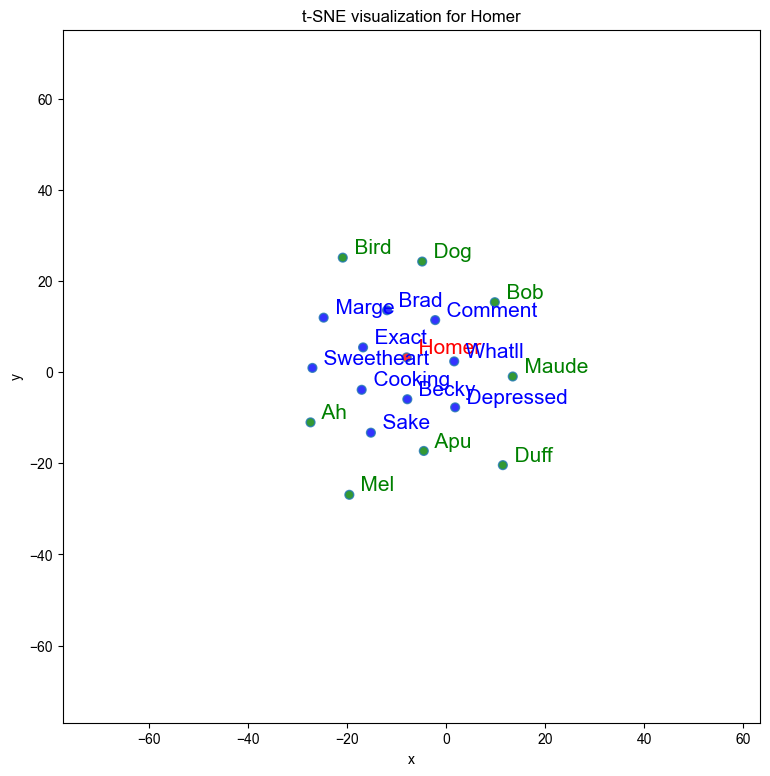

In [ ]:
# Let's compare where the vector representation of Homer, his 10 most similar words from the model,
#  as well as 8 random ones, lies in a 2D graph:
tsnescatterplot(w2v_model, 'homer', ['dog', 'bird', 'ah', 'maude', 'bob', 'mel', 'apu', 'duff'])

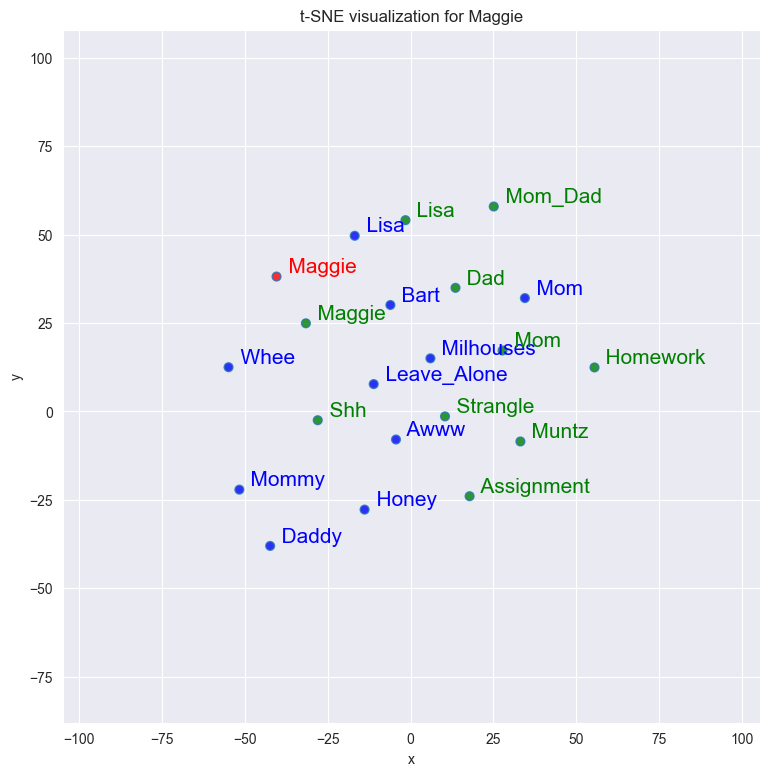

In [ ]:
# Let's compare where the vector representation of Maggie and her 10 most similar words from the model lies
#  compare to the vector representation of the 10 most dissimilar words to Maggie
tsnescatterplot(w2v_model, 'maggie', [i[0] for i in w2v_model.wv.most_similar(positive=["bart"])])

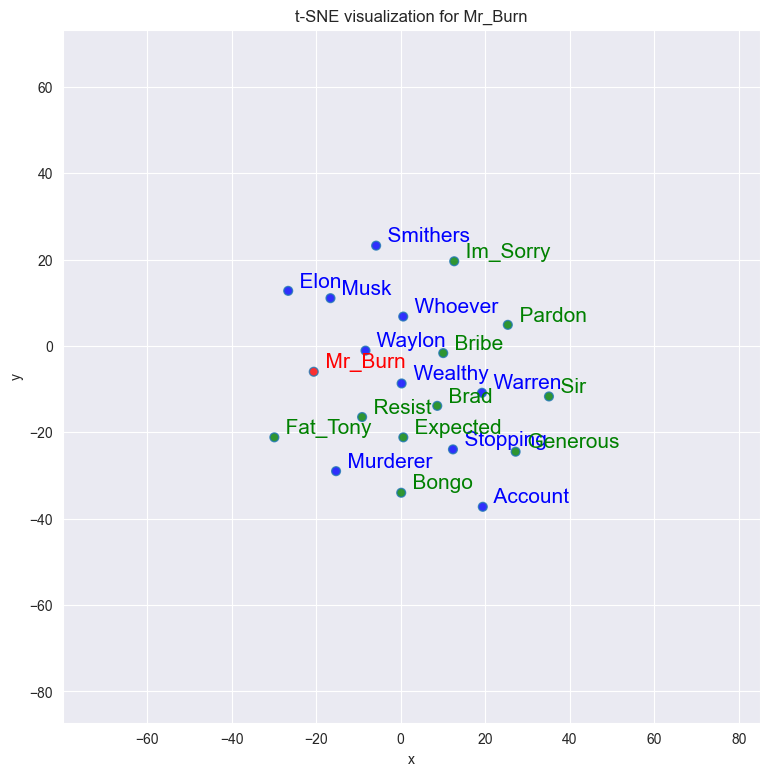

In [ ]:
# plot the most similar words to Mr. Burns ranked 1st to 10th versus the ones ranked 11th to 20th
tsnescatterplot(w2v_model, "mr_burn", [t[0] for t in w2v_model.wv.most_similar(positive=["mr_burn"], topn=20)][10:])